# 🛒 Retail Sales & Customer Segmentation Analytics
**By Prudhvi Raj Challa**

### Objective
Analyze 2+ years of retail sales data to identify revenue trends, top-performing products, regional performance, and segment customers using RFM analysis.

### Tools Used
- Python (Pandas, NumPy, Matplotlib, Seaborn)
- SQL (SQLite)
- RFM Segmentation
- Power BI (Dashboard)

## 📦 STEP 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 🧹 STEP 2: Load & Clean Data

In [2]:
# Load dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nNull Values:\n', df.isnull().sum())
print('\nData Types:\n', df.dtypes)

Shape: (9994, 21)

Column Names: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Null Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State           

In [3]:
# Fix data types
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Remove duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f'Duplicates removed: {before - after}')

# Add new useful columns
df['Year']          = df['Order Date'].dt.year
df['Month']         = df['Order Date'].dt.month
df['Month_Name']    = df['Order Date'].dt.strftime('%b')
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print('\n✅ Data cleaned! Final shape:', df.shape)
df.head()

Duplicates removed: 0

✅ Data cleaned! Final shape: (9994, 25)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Name,Delivery Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Nov,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Nov,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Jun,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Oct,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Oct,7


## 🔍 STEP 3: Exploratory Data Analysis (EDA)

In [4]:
# Basic Statistics
print('📊 KEY BUSINESS METRICS')
print('========================')
print(f'Total Revenue  : ${df["Sales"].sum():,.2f}')
print(f'Total Profit   : ${df["Profit"].sum():,.2f}')
print(f'Total Orders   : {df["Order ID"].nunique()}')
print(f'Total Customers: {df["Customer Name"].nunique()}')
print(f'Total Products : {df["Product Name"].nunique()}')
print(f'Avg Delivery   : {df["Delivery Days"].mean():.1f} days')

📊 KEY BUSINESS METRICS
Total Revenue  : $2,297,200.86
Total Profit   : $286,397.02
Total Orders   : 5009
Total Customers: 793
Total Products : 1850
Avg Delivery   : 4.0 days


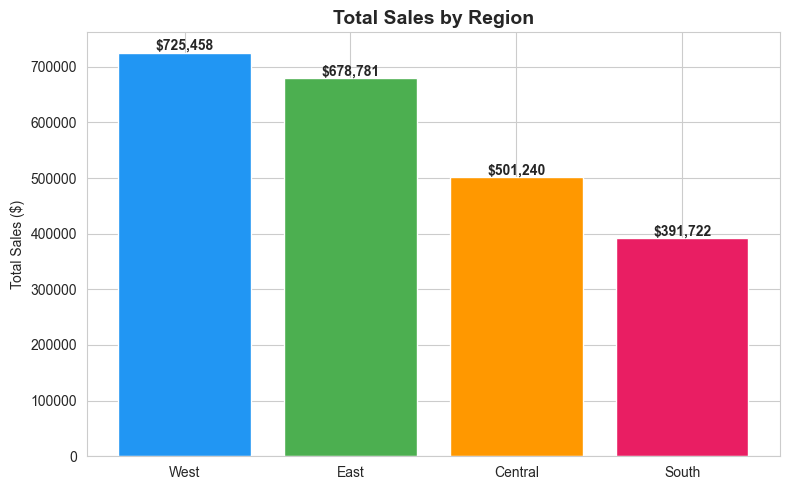

In [5]:
# Plot 1: Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars = plt.bar(region_sales.index, region_sales.values, 
               color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
for bar, val in zip(bars, region_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('plot1_sales_by_region.png', dpi=150)
plt.show()

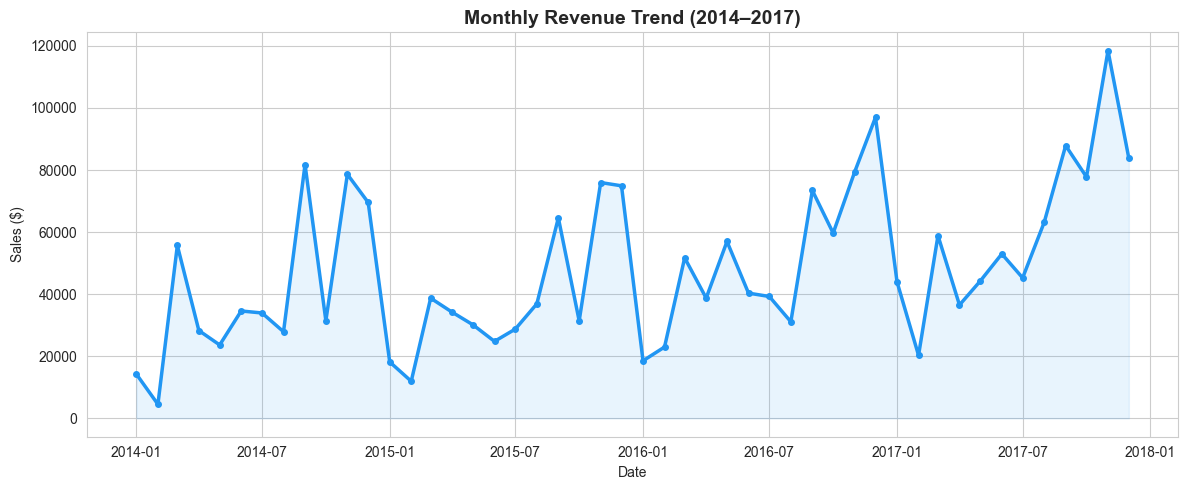

In [6]:
# Plot 2: Monthly Revenue Trend
monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly['Period'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

plt.figure(figsize=(12,5))
plt.plot(monthly['Period'], monthly['Sales'], color='#2196F3', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(monthly['Period'], monthly['Sales'], alpha=0.1, color='#2196F3')
plt.title('Monthly Revenue Trend (2014–2017)', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('plot2_monthly_trend.png', dpi=150)
plt.show()

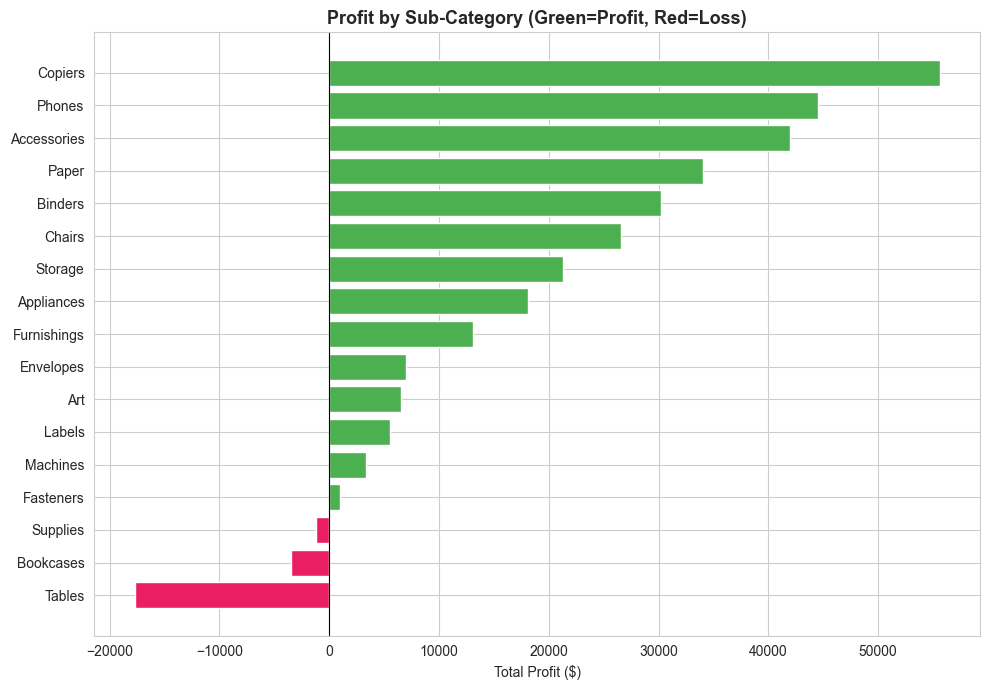

In [7]:
# Plot 3: Profit by Sub-Category
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#E91E63' if x < 0 else '#4CAF50' for x in sub_profit.values]

plt.figure(figsize=(10,7))
plt.barh(sub_profit.index, sub_profit.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Profit by Sub-Category (Green=Profit, Red=Loss)', fontsize=13, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('plot3_profit_subcategory.png', dpi=150)
plt.show()

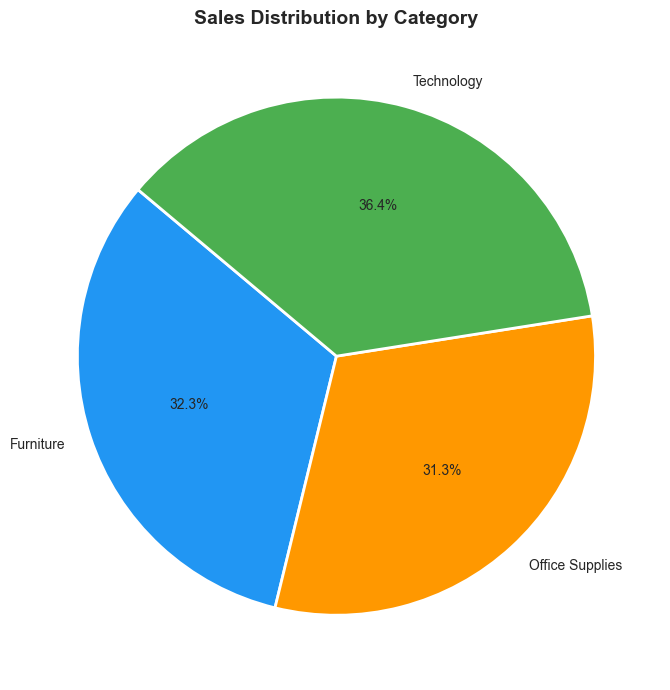

In [8]:
# Plot 4: Sales by Category (Pie)
cat_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(cat_sales.values, labels=cat_sales.index, autopct='%1.1f%%',
        colors=['#2196F3','#FF9800','#4CAF50'], startangle=140,
        wedgeprops={'edgecolor':'white','linewidth':2})
plt.title('Sales Distribution by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_category_pie.png', dpi=150)
plt.show()

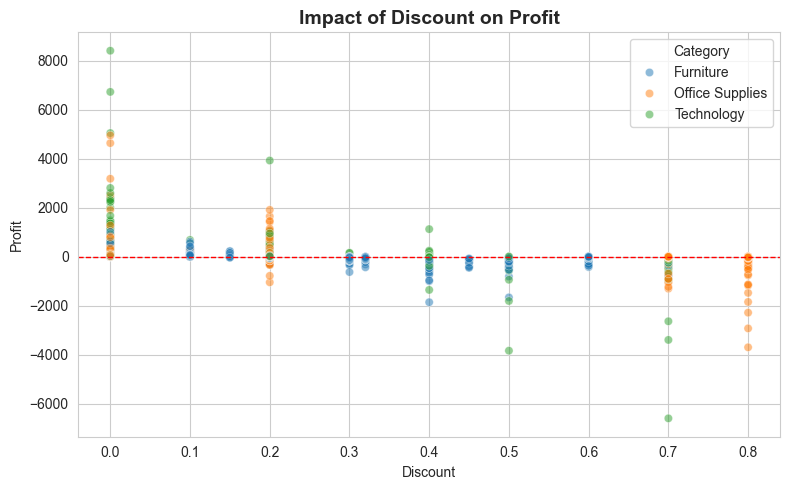


💡 Insight: Higher discounts (>0.4) consistently lead to losses!


In [9]:
# Plot 5: Discount vs Profit (Scatter)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.5)
plt.title('Impact of Discount on Profit', fontsize=14, fontweight='bold')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('plot5_discount_vs_profit.png', dpi=150)
plt.show()
print('\n💡 Insight: Higher discounts (>0.4) consistently lead to losses!')

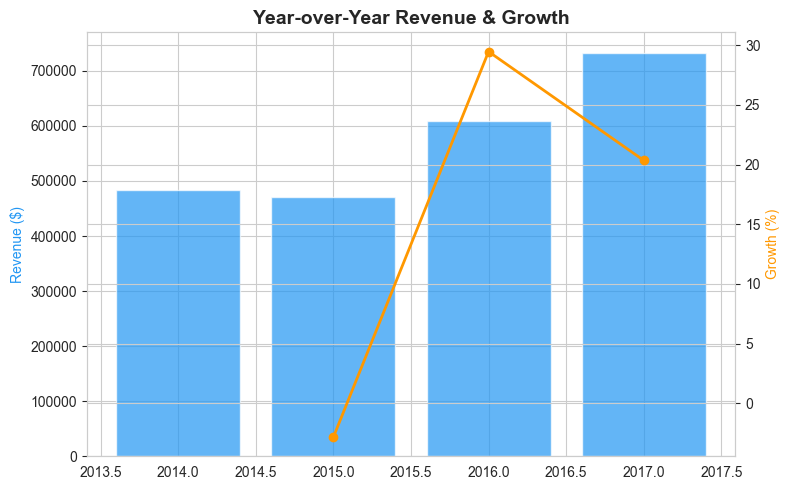

In [10]:
# Plot 6: Year-over-Year Revenue Growth
yoy = df.groupby('Year')['Sales'].sum()
growth = yoy.pct_change() * 100

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.bar(yoy.index, yoy.values, color='#2196F3', alpha=0.7, label='Revenue')
ax2 = ax1.twinx()
ax2.plot(yoy.index[1:], growth[1:], color='#FF9800', marker='o', linewidth=2, label='Growth %')
ax1.set_title('Year-over-Year Revenue & Growth', fontsize=14, fontweight='bold')
ax1.set_ylabel('Revenue ($)', color='#2196F3')
ax2.set_ylabel('Growth (%)', color='#FF9800')
plt.tight_layout()
plt.savefig('plot6_yoy_growth.png', dpi=150)
plt.show()

## 🗄️ STEP 4: SQL Analysis

In [11]:
# Save to SQLite database
conn = sqlite3.connect('superstore.db')
df.to_sql('sales', conn, if_exists='replace', index=False)
print('✅ Data loaded into SQL database')

✅ Data loaded into SQL database


In [12]:
# Query 1: Sales by Region
q1 = pd.read_sql('''
    SELECT Region, 
           ROUND(SUM(Sales),2) AS Total_Sales,
           ROUND(SUM(Profit),2) AS Total_Profit,
           COUNT(DISTINCT "Order ID") AS Total_Orders
    FROM sales 
    GROUP BY Region 
    ORDER BY Total_Sales DESC
''', conn)
print('📊 Sales by Region:')
q1

📊 Sales by Region:


,Region,Total_Sales,Total_Profit,Total_Orders
0,West,725457.82,108418.45,1611
1,East,678781.24,91522.78,1401
2,Central,501239.89,39706.36,1175
3,South,391721.91,46749.43,822


In [13]:
# Query 2: Category Performance
q2 = pd.read_sql('''
    SELECT Category,
           ROUND(SUM(Sales),2) AS Total_Sales,
           ROUND(SUM(Profit),2) AS Total_Profit,
           ROUND(AVG(Discount)*100,1) AS Avg_Discount_Pct
    FROM sales 
    GROUP BY Category 
    ORDER BY Total_Profit DESC
''', conn)
print('📊 Category Performance:')
q2

📊 Category Performance:


,Category,Total_Sales,Total_Profit,Avg_Discount_Pct
0,Technology,836154.03,145454.95,13.2
1,Office Supplies,719047.03,122490.80,15.7
2,Furniture,741999.80,18451.27,17.4


In [14]:
# Query 3: Year-over-Year Revenue
q3 = pd.read_sql('''
    SELECT Year, 
           ROUND(SUM(Sales),2) AS Revenue,
           COUNT(DISTINCT "Order ID") AS Orders
    FROM sales 
    GROUP BY Year 
    ORDER BY Year
''', conn)
print('📊 Year-over-Year Revenue:')
q3

📊 Year-over-Year Revenue:


,Year,Revenue,Orders
0,2014,484247.50,969
1,2015,470532.51,1038
2,2016,609205.60,1315
3,2017,733215.26,1687


In [15]:
# Query 4: Top 10 Customers
q4 = pd.read_sql('''
    SELECT "Customer Name", 
           ROUND(SUM(Sales),2) AS Revenue,
           COUNT(DISTINCT "Order ID") AS Orders,
           ROUND(SUM(Profit),2) AS Profit
    FROM sales 
    GROUP BY "Customer Name" 
    ORDER BY Revenue DESC 
    LIMIT 10
''', conn)
print('📊 Top 10 Customers:')
q4

📊 Top 10 Customers:


,Customer Name,Revenue,Orders,Profit
0,Sean Miller,25043.05,5,-1980.74
1,Tamara Chand,19052.22,5,8981.32
2,Raymond Buch,15117.34,6,6976.10
3,Tom Ashbrook,14595.62,4,4703.79
4,Adrian Barton,14473.57,10,5444.81
5,Ken Lonsdale,14175.23,12,806.85
6,Sanjit Chand,14142.33,9,5757.41
7,Hunter Lopez,12873.30,6,5622.43
8,Sanjit Engle,12209.44,11,2650.68
9,Christopher Conant,12129.07,5,2177.05


In [16]:
# Query 5: Loss-making Sub-Categories
q5 = pd.read_sql('''
    SELECT "Sub-Category",
           ROUND(SUM(Sales),2) AS Sales,
           ROUND(SUM(Profit),2) AS Profit
    FROM sales
    GROUP BY "Sub-Category"
    HAVING Profit < 0
    ORDER BY Profit ASC
''', conn)
print('📊 Loss-Making Sub-Categories:')
q5

📊 Loss-Making Sub-Categories:


,Sub-Category,Sales,Profit
0,Tables,206965.53,-17725.48
1,Machines,189238.63,3384.76


## 👥 STEP 5: RFM Customer Segmentation

In [17]:
# Calculate RFM values
snapshot = df['Order Date'].max() + datetime.timedelta(days=1)

rfm = df.groupby('Customer Name').agg(
    Recency   = ('Order Date',  lambda x: (snapshot - x.max()).days),
    Frequency = ('Order ID',    'nunique'),
    Monetary  = ('Sales',       'sum')
).reset_index()

# Score 1-3
rfm['R'] = pd.qcut(rfm['Recency'],   3, labels=[3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1,2,3])
rfm['M'] = pd.qcut(rfm['Monetary'],  3, labels=[1,2,3])

# Segment
def segment(row):
    score = int(row['R']) + int(row['F']) + int(row['M'])
    if score >= 8:   return 'Champions'
    elif score >= 5: return 'At-Risk'
    else:            return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm.to_csv('rfm_segments.csv', index=False)

print('👥 Customer Segments:')
print(rfm['Segment'].value_counts())
rfm.head(10)

👥 Customer Segments:
Segment
At-Risk      415
Lost         189
Champions    189
Name: count, dtype: int64


,Customer Name,Recency,Frequency,Monetary,R,F,M,Segment
0,Aaron Bergman,416,3,886.156,1,1,1,Lost
1,Aaron Hawkins,13,7,1744.700,3,2,2,At-Risk
2,Aaron Smayling,89,7,3050.692,2,2,2,At-Risk
3,Adam Bellavance,55,8,7755.620,2,3,3,Champions
4,Adam Hart,35,10,3250.337,3,3,3,Champions
5,Adam Shillingsburg,29,9,3255.310,3,3,3,Champions
6,Adrian Barton,42,10,14473.571,3,3,3,Champions
7,Adrian Hane,61,7,1735.514,2,2,2,At-Risk
8,Adrian Shami,42,2,58.820,3,1,1,At-Risk
9,Aimee Bixby,42,5,966.710,3,1,1,At-Risk


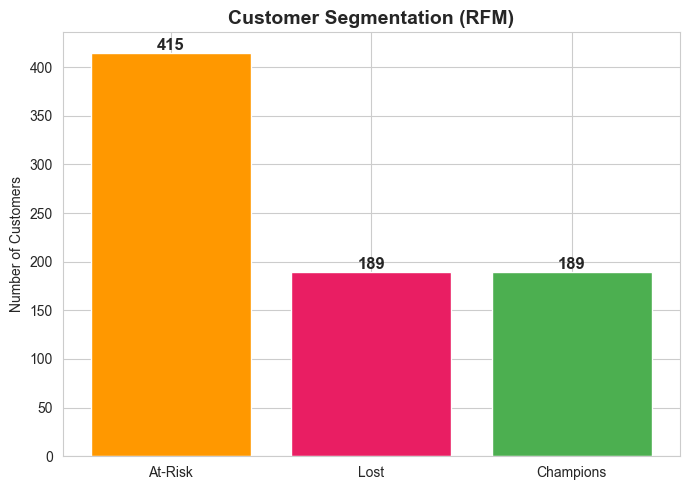

In [18]:
# Plot: RFM Segment Distribution
seg_counts = rfm['Segment'].value_counts()
colors_seg = {'Champions': '#4CAF50', 'At-Risk': '#FF9800', 'Lost': '#E91E63'}

plt.figure(figsize=(7,5))
bars = plt.bar(seg_counts.index, seg_counts.values,
               color=[colors_seg[s] for s in seg_counts.index])
for bar, val in zip(bars, seg_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', fontweight='bold', fontsize=12)
plt.title('Customer Segmentation (RFM)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('plot7_rfm_segments.png', dpi=150)
plt.show()

## 💡 STEP 6: Business Insights & Recommendations

In [19]:
print('='*55)
print('       📋 KEY BUSINESS INSIGHTS')
print('='*55)

total_rev   = df['Sales'].sum()
total_prof  = df['Profit'].sum()
margin      = (total_prof / total_rev) * 100
top_region  = df.groupby('Region')['Sales'].sum().idxmax()
loss_cats   = df.groupby('Sub-Category')['Profit'].sum()
loss_list   = loss_cats[loss_cats < 0].index.tolist()
high_disc   = df[df['Discount'] > 0.4]['Profit'].mean()
low_disc    = df[df['Discount'] <= 0.2]['Profit'].mean()

print(f'\n1️⃣  Overall profit margin is {margin:.1f}%')
print(f'2️⃣  {top_region} is the highest revenue region')
print(f'3️⃣  Loss-making sub-categories: {loss_list}')
print(f'4️⃣  High discount (>40%) avg profit: ${high_disc:.2f}')
print(f'   Low discount (≤20%) avg profit : ${low_disc:.2f}')
print(f'5️⃣  {rfm[rfm["Segment"]=="Lost"].shape[0]} Lost customers need re-engagement campaigns')
print(f'6️⃣  {rfm[rfm["Segment"]=="Champions"].shape[0]} Champion customers drive premium revenue')
print('\n✅ Project Complete! Ready for Power BI Dashboard.')

       📋 KEY BUSINESS INSIGHTS

1️⃣  Overall profit margin is 12.5%
2️⃣  West is the highest revenue region
3️⃣  Loss-making sub-categories: ['Bookcases', 'Supplies', 'Tables']
4️⃣  High discount (>40%) avg profit: $-106.71
   Low discount (≤20%) avg profit : $49.04
5️⃣  189 Lost customers need re-engagement campaigns
6️⃣  189 Champion customers drive premium revenue

✅ Project Complete! Ready for Power BI Dashboard.


## 📁 Output Files Generated
- `superstore_cleaned.csv` — cleaned dataset for Power BI
- `rfm_segments.csv` — RFM customer segments for Power BI
- `plot1_sales_by_region.png` through `plot7_rfm_segments.png` — all charts
- `superstore.db` — SQLite database